### Greens Representation Model:

# $G(p, s)=-\frac{e^{i k d(p, s)}}{4 \pi d(p, s)}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from holograPy_functions import points_vector_builder, coords_shape, GF_propagator_function_builder

In [2]:
# ---> physics params <---
c0 = 343.  # [m/s]
v = 40000  # [Hz]
lam = c0 / v  # [m]
k = 2 * np.pi / lam  # [rads/m]
resolution = 4

# ---> location of the focus <---
focal_point = (0, 0, 10*lam)

# ----> reflector plane <----
m_ref, n_ref = 32, 32
dx_ref = lam/2 # cell spacing [m]
ref_centrepoint = (0, 0, 0)
ref_sidelengths = [((m_ref/2)*dx_ref, (m_ref/2)*dx_ref),
                   ((n_ref/2)*dx_ref, (n_ref/2)*dx_ref),
                   (0, 0)]
ref_points = points_vector_builder(ref_centrepoint, ref_sidelengths, dx_ref)

# ----> normals & areas <----
ref_normals = [np.zeros((1, n_ref*m_ref)),
                     np.zeros((1, n_ref*m_ref)),
                     np.ones((1, n_ref*m_ref))]
ref_areas = (dx_ref**2)*np.ones((1, n_ref*m_ref))

# ----> xz_eval plane calculation <----
dx_xz_eval = (lam/2)/resolution
# xz_eval_centrepoint = focal_point
xz_eval_centrepoint = (0, 0, 10*lam)
xz_eval_sidelengths = [(5*lam, 5*lam), (0, 0), (focal_point[2], focal_point[2])] # [(-x, +x), (-y, +y), (-z, +z)]
xz_eval_points = points_vector_builder(xz_eval_centrepoint, xz_eval_sidelengths, dx_xz_eval)

# ----> xy_eval plane calculation <----
dx_xy_eval = (lam/2)/resolution
# xy_eval_centrepoint = focal_point
xy_eval_centrepoint = (0, 0, 10*lam)
xy_eval_sidelengths = [(5*lam, 5*lam), (5*lam, 5*lam), (0, 0)] # [(-x, +x), (-y, +y), (-z, +z)]
xy_eval_points = points_vector_builder(xy_eval_centrepoint, xy_eval_sidelengths, dx_xy_eval)

In [3]:
# ----> focussing transducer complex pressure with backprop <----
A_magnitude = 1
H_focus_ref = GF_propagator_function_builder(ref_points, np.array([focal_point]),
                                                   ref_normals, ref_areas, k)
P_focus = A_magnitude*np.ones(1)*np.exp(1j*np.ones(1))
phasemap = np.angle(np.dot(P_focus.reshape(-1, 1), np.conj(H_focus_ref.reshape(1, -1))))
phasemap = np.mod(phasemap, 2*np.pi) - np.pi

In [4]:
# ----> propagating <----
Pt = A_magnitude*np.ones((m_ref*n_ref))*np.exp(1j*phasemap)

# ----> xz eval plane propagation <----
H_xz = GF_propagator_function_builder(ref_points, xz_eval_points,
                                      ref_normals, ref_areas, k)
H_xz = H_xz.reshape(m_ref*n_ref, -1)
Pf_xz = np.dot(Pt, H_xz).reshape(coords_shape(xz_eval_sidelengths, resolution, lam))

# ----> xy eval plane propagation <----
H_xy = GF_propagator_function_builder(ref_points, xy_eval_points,
                                      ref_normals, ref_areas, k)
H_xy = H_xy.reshape(m_ref*n_ref, -1)
Pf_xy = np.dot(Pt, H_xy).reshape(coords_shape(xy_eval_sidelengths, resolution, lam))

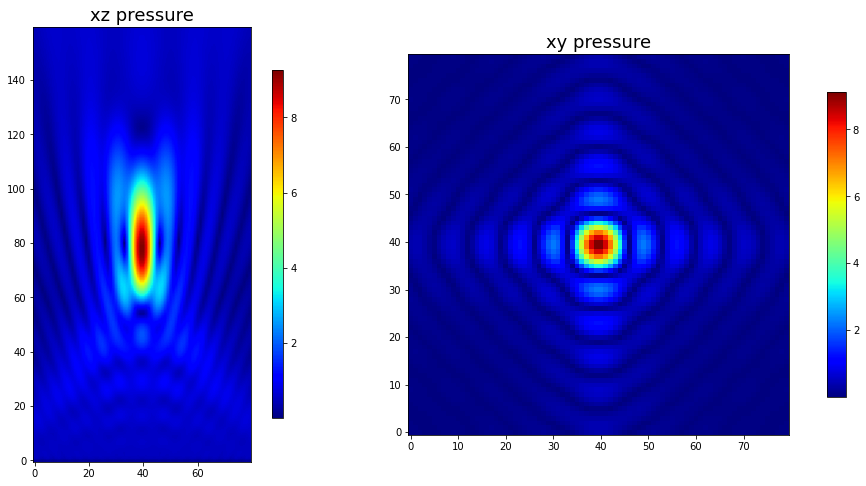

In [5]:
# ----> plotting <----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

im1 = ax1.imshow(abs(Pf_xz), plt.get_cmap("jet"), origin="lower")
cax = ax1.inset_axes([1.1, 0.1, 0.05, 0.8]) # [x0, y0, width, height]
ax1.set_title("xz pressure", fontsize=18)
plt.colorbar(im1, cax=cax)

im2 = ax2.imshow(abs(Pf_xy), plt.get_cmap("jet"), origin="lower")
cax = ax2.inset_axes([1.1, 0.1, 0.05, 0.8]) # [x0, y0, width, height]
ax2.set_title("xy pressure", fontsize=18)
plt.colorbar(im2, cax=cax)

plt.show()